# Tarea 2 - Minería de Datos

## Análisis de Pokémon según características de combate

El objetivo de este trabajo es identificar grupos de Pokémon con estilos de combate similares usando técnicas de clustering. Para ello se utilizarán variables relacionadas con vida, ataque, defensa, ataque especial, defensa especial y velocidad.

Se aplicarán tres métodos de agrupamiento:

- K-Means
- Clustering jerárquico
- DBSCAN

Finalmente, se compararán los resultados y se seleccionará el método más adecuado para interpretar los estilos de combate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Pokemon.csv")
df.head()

,ID,Name,Form,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,Bulbasaur,,Grass,Poison,318,45,49,49,65,65,45,1
1,2,Ivysaur,,Grass,Poison,405,60,62,63,80,80,60,1
2,3,Venusaur,,Grass,Poison,525,80,82,83,100,100,80,1
3,4,Charmander,,Fire,,309,39,52,43,60,50,65,1
4,5,Charmeleon,,Fire,,405,58,64,58,80,65,80,1


In [2]:
df.columns
variables_base = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
df_base = df[variables_base].copy()
df_base.head()

#A partir de ahora trabajamos con df_base   

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,39,52,43,60,50,65
4,58,64,58,80,65,80


In [3]:
from IPython.display import display

print("Información general del dataset:")
df_base.info()
print("\nValores nulos por columna:")
display(df_base.isnull().sum())
print("\nEstadísticas descriptivas:")
display(df_base.describe())
print("\nCantidad de filas duplicadas en las variables seleccionadas:")
display(df_base.duplicated(keep = False).sum())


Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   HP       1215 non-null   int64
 1   Attack   1215 non-null   int64
 2   Defense  1215 non-null   int64
 3   Sp. Atk  1215 non-null   int64
 4   Sp. Def  1215 non-null   int64
 5   Speed    1215 non-null   int64
dtypes: int64(6)
memory usage: 57.1 KB

Valores nulos por columna:


HP         0
Attack     0
Defense    0
Sp. Atk    0
Sp. Def    0
Speed      0
dtype: int64


Estadísticas descriptivas:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000,1215.000000
mean,71.244444,81.152263,75.007407,73.224691,72.441152,70.034568
std,26.927819,32.037134,30.740999,32.757152,27.578188,30.161298
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,52.000000,57.000000,52.000000,50.000000,51.000000,45.000000
50%,70.000000,80.000000,70.000000,65.000000,70.000000,68.000000
75%,85.000000,100.000000,91.000000,95.000000,90.000000,91.000000
max,255.000000,190.000000,250.000000,194.000000,250.000000,200.000000



Cantidad de filas duplicadas en las variables seleccionadas:


np.int64(127)

### Interpretación de la limpieza de datos

El dataset contiene 1215 registros y 6 variables numéricas asociadas al rendimiento de combate de los Pokémon: HP, Attack, Defense, Sp. Atk, Sp. Def y Speed.

No se encontraron valores nulos en ninguna de las variables seleccionadas, por lo que no fue necesario imputar ni eliminar registros por datos faltantes. Además, todas las columnas son numéricas de tipo entero, lo que permite utilizarlas directamente en procedimientos posteriores de ingeniería de atributos, normalización y clustering.

Las estadísticas descriptivas muestran que las variables presentan rangos distintos. Por ejemplo, HP varía entre 1 y 255, Attack entre 5 y 190, Defense entre 5 y 250, Sp. Atk entre 10 y 194, Sp. Def entre 20 y 250, y Speed entre 5 y 200. Estas diferencias de escala justifican la necesidad de aplicar normalización o estandarización antes de usar algoritmos basados en distancia.

También se detectaron 127 filas duplicadas  considerando solo las variables seleccionadas. Sin embargo, no se eliminaron, ya que distintos Pokémon pueden compartir exactamente los mismos atributos de combate. Eliminarlos podría significar perder observaciones válidas del conjunto de datos.

Como grupo, coincidimos en que los datos están limpios y listos para ingeniería de atributos.

## 3. Ingeniería de Atributos

En esta etapa se construyen nuevas variables a partir de los atributos originales de combate. El objetivo es representar de mejor manera el estilo de cada Pokémon, incorporando medidas agregadas de ofensiva, defensa, velocidad relativa, supervivencia y orientación física o especial.

Estas nuevas variables permiten que los algoritmos de clustering trabajen con características más interpretables que las variables originales por separado.

In [4]:
df_features = df_base.copy()
df_features["Offense_Total"] = df_features["Attack"] + df_features["Sp. Atk"] 
df_features["Defense_Total"] = df_features["Defense"] + df_features["Sp. Def"]
df_features["Off_Def_Ratio"] = df_features["Attack"] / (df_features["Defense"] + 1)
df_features["Speed_Index"] = df_features["Speed"] / (df_features["HP"] + 1)
df_features["Bulk"] = df_features["HP"] * (df_features["Defense"] + df_features["Sp. Def"])
df_features["Phys_Special"] = df_features["Attack"] - df_features["Sp. Atk"]
df_features.head()

nuevos_atributos = ['Offense_Total', 'Defense_Total', 'Off_Def_Ratio', 'Speed_Index', 'Bulk', 'Phys_Special']
df_features = df_features[nuevos_atributos]
df_features.head()

,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
0,114,114,0.980000,0.978261,5130,-16
1,142,143,0.968750,0.983607,8580,-18
2,182,183,0.976190,0.987654,14640,-18
3,112,93,1.181818,1.625000,3627,-8
4,144,123,1.084746,1.355932,7134,-16


### Interpretación de la ingeniería de atributos

Las nuevas variables creadas permiten representar de forma más clara los estilos de combate de cada Pokémon. `Offense_Total` y `Defense_Total` resumen la capacidad ofensiva y defensiva general. `Off_Def_Ratio` permite observar si un Pokémon tiende a ser más ofensivo o defensivo desde el punto de vista físico.

`Speed_Index` relaciona la velocidad con el HP, por lo que ayuda a identificar Pokémon rápidos en relación con su resistencia. `Bulk` mide la capacidad de supervivencia combinando HP y defensas. Finalmente, `Phys_Special` permite distinguir si el Pokémon se orienta más hacia el ataque físico, el ataque especial o si mantiene un perfil balanceado.

Estas variables serán utilizadas en los pasos posteriores para normalizar los datos y aplicar los algoritmos de clustering.

## 4. Normalización de Datos

Los algoritmos de clustering utilizados en este trabajo se basan en distancias entre observaciones. Por esta razón, es necesario que todas las variables estén en una escala comparable.

En este caso se utilizó `StandardScaler`, que transforma cada variable restando su media y dividiendo por su desviación estándar. Esto permite que variables con magnitudes grandes, como `Bulk`, no dominen artificialmente el cálculo de distancias frente a variables más pequeñas, como `Off_Def_Ratio` o `Speed_Index`.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_features.columns)
X_scaled_df.head()
X_scaled_df.describe().round(3)

,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
count,1215.000,1215.000,1215.000,1215.000,1215.000,1215.000
mean,0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.546,-2.202,-2.224,-1.247,-1.582,-3.540
25%,-0.746,-0.733,-0.635,-0.500,-0.722,-0.637
50%,-0.083,-0.048,-0.171,-0.121,-0.125,-0.078
75%,0.675,0.638,0.518,0.307,0.540,0.614
max,3.896,6.905,14.928,22.532,16.745,3.650


### Interpretación de la normalización

Luego de aplicar `StandardScaler`, las variables quedaron expresadas en una escala común. Esto es importante porque los métodos de clustering que se aplicarán posteriormente utilizan distancias entre observaciones.

Sin normalización, variables con valores muy grandes, como `Bulk`, tendrían un peso excesivo en la formación de clusters. Al estandarizar, cada variable aporta de manera más equilibrada al análisis.

La tabla descriptiva posterior a la estandarización confirma que las variables quedaron con media cercana a 0 y desviación estándar cercana a 1. Sin embargo, algunos valores máximos estandarizados siguen siendo altos, lo que sugiere la presencia de observaciones extremas. Por esta razón, el siguiente paso será aplicar un método de detección de outliers.

## 5. Detección de Outliers

En esta etapa se busca identificar observaciones atípicas dentro del conjunto de datos. Un outlier corresponde a un Pokémon cuyos atributos de combate se alejan del patrón general de la mayoría de observaciones.

Para este análisis se utilizó `Local Outlier Factor` (LOF), un algoritmo que compara la densidad local de cada observación con la densidad de sus vecinos. Si un punto se encuentra en una región mucho menos densa que sus vecinos, puede ser marcado como atípico.

En este contexto, los outliers no necesariamente corresponden a errores. Pueden representar Pokémon con estadísticas muy particulares, como Pokémon legendarios, extremadamente defensivos, muy rápidos o con combinaciones poco comunes de atributos. Por esta razón, se identificarán y analizarán, pero no se eliminarán automáticamente.

In [6]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)
outlier_labels = lof.fit_predict(X_scaled_df)
df_features["Outlier_LOF"] = outlier_labels
df_features["Outlier_LOF"].value_counts()
cantidad_outliers = (df_features["Outlier_LOF"] == -1).sum()
porcentaje_outliers = (cantidad_outliers / len(df_features)) * 100
print("Cantidad de outliers detectados:", cantidad_outliers)
print("Porcentaje de outliers detectados:", round(porcentaje_outliers, 2), "%")

Cantidad de outliers detectados: 59
Porcentaje de outliers detectados: 4.86 %


### Interpretación de la detección de outliers

El algoritmo LOF identificó 59 observaciones atípicas, equivalentes aproximadamente al aproximado 5% del conjunto de datos. 

Al revisar los Pokémon detectados como outliers, se observa que muchos presentan combinaciones extremas de atributos. Por ejemplo, algunos tienen HP muy alto, defensas muy elevadas, velocidad extrema o estadísticas ofensivas muy bajas. Esto sugiere que los outliers no corresponden necesariamente a errores en los datos, sino a Pokémon con perfiles de combate poco comunes.

Por esta razón, los outliers no fueron eliminados automáticamente. En el contexto del problema, estas observaciones pueden ser relevantes para identificar estilos de combate especiales o extremos.

## 6. Agrupamiento con K-Means

En esta etapa se aplicará el algoritmo K-Means para agrupar Pokémon con características de combate similares.

K-Means busca dividir las observaciones en `k` grupos, minimizando la distancia entre cada observación y el centroide de su cluster. Como este método depende de distancias, se utilizan los datos previamente estandarizados.

Para seleccionar el número de clusters se utilizarán dos criterios: el método del codo y el Silhouette Score.

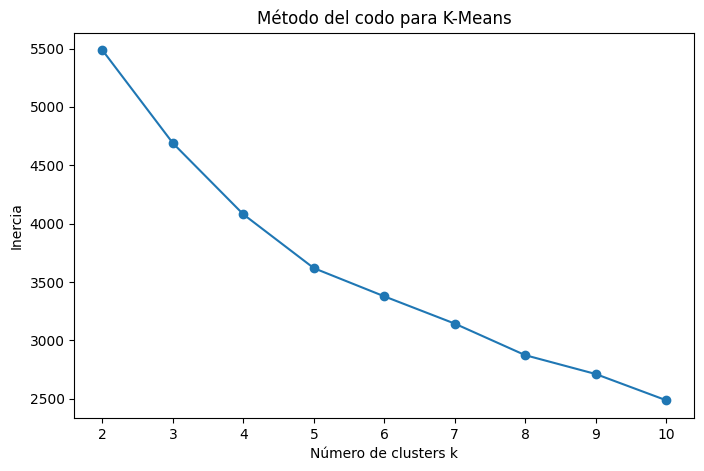

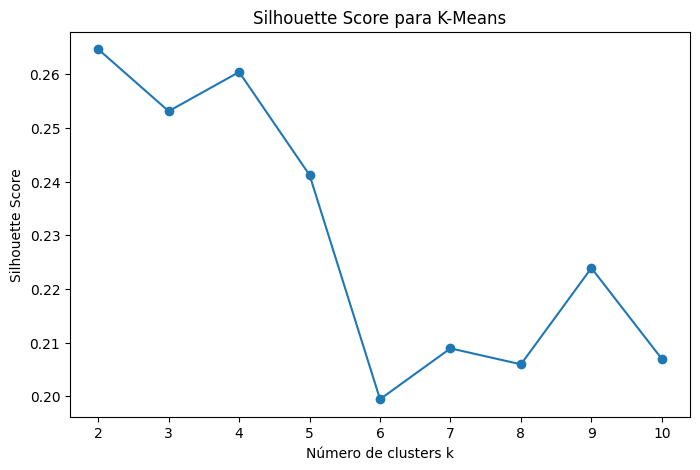

,k,Inercia,Silhouette
0,2,5485.327973,0.264653
1,3,4688.748468,0.253108
2,4,4079.142709,0.260405
3,5,3618.435788,0.241207
4,6,3376.828213,0.199437
5,7,3143.195206,0.208918
6,8,2872.833598,0.205940
7,9,2711.451285,0.223883
8,10,2486.791081,0.206947


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Matriz de datos para clustering
X_model = X_scaled_df.copy()

inertias = []
silhouettes = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_model)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_model, labels))
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Inercia")
plt.title("Método del codo para K-Means")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouettes, marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para K-Means")
plt.show()

df_kmeans_scores = pd.DataFrame({"k": list(K_range),"Inercia": inertias,"Silhouette": silhouettes})
df_kmeans_scores

## 6. Elección del número de clusters para K-Means 
Para seleccionar el número de clusters se analizaron el método del codo y el Silhouette Score.

El método del codo muestra una disminución importante de la inercia entre k = 2 y k = 3. A partir de ese punto, la reducción de la inercia continúa, pero de forma más gradual. Esto sugiere que agregar más clusters después de k = 3 entrega mejoras menores en compactación.

Por otro lado, el mayor Silhouette Score se obtiene con k = 2. Sin embargo, para el objetivo del problema, dos grupos resultan demasiado generales para describir distintos estilos de combate Pokémon.

Adicionalmente, se probaron valores de k = 4, k = 5 y k = 6, pero en todos los casos K-Means generaba al menos un cluster con menos de 10 observaciones. Esto indica que el algoritmo aísla observaciones extremas en clusters propios en lugar de identificar un estilo de combate real adicional. Por esta razón, agregar más clusters no aporta interpretabilidad.

En consecuencia, para K-Means se utilizarán 3 clusters, que permiten una segmentación interpretable, equilibrada en tamaño y consistente con la estructura natural de los datos.

In [8]:
k_kmeans = 3

kmeans_final = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
df_features["Cluster_KMeans"] = kmeans_final.fit_predict(X_model)
df_features["Cluster_KMeans"].value_counts().sort_index()

Cluster_KMeans
0    488
1    392
2    335
Name: count, dtype: int64

In [9]:
resumen_kmeans = df_features.groupby("Cluster_KMeans")[
    ["Offense_Total","Defense_Total","Off_Def_Ratio","Speed_Index","Bulk",
        "Phys_Special"]
].mean().round(2)
resumen_kmeans

,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
Cluster_KMeans,,,,,,
0,109.02,106.12,1.09,1.21,5745.89,2.94
1,182.04,195.55,0.88,0.92,16446.86,-15.02
2,188.07,151.37,1.55,1.09,12540.81,42.05


## 7. Agrupamiento con clustering jerárquico



In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Cálculo de la matriz de linkage usando método Ward
Z = linkage(X_model, method="ward")

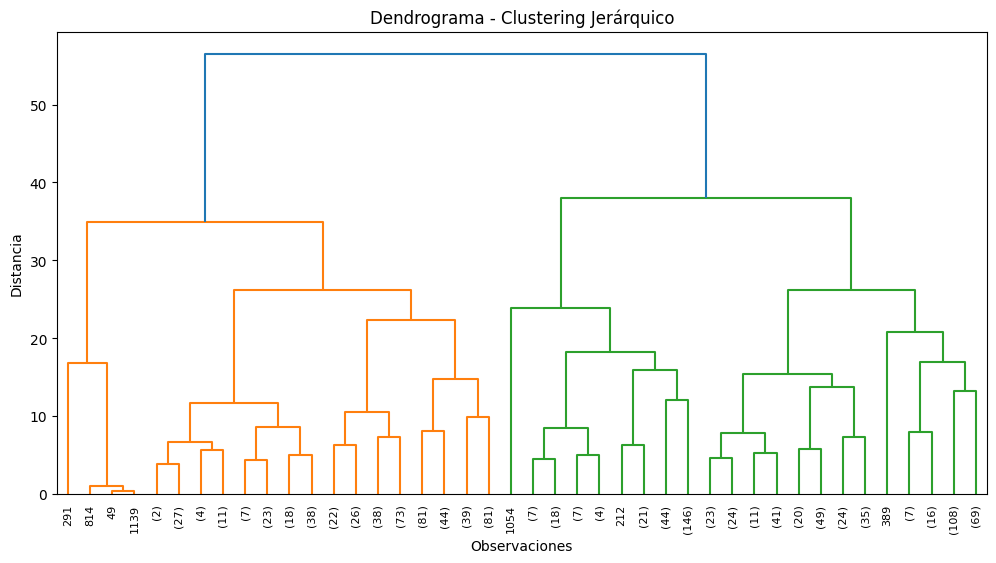

In [11]:
plt.figure(figsize=(12, 6))
dendrogram(Z,truncate_mode="level",p=5)

plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

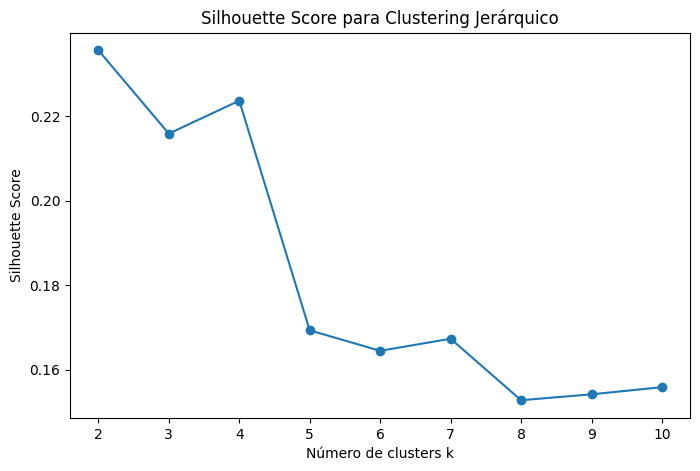

,k,Silhouette
0,2,0.235674
1,3,0.215910
2,4,0.223716
3,5,0.169307
4,6,0.164450
5,7,0.167312
6,8,0.152744
7,9,0.154142
8,10,0.155834


In [12]:
silhouettes_hier = []
K_range = range(2, 11)
for k in K_range:
    hierarchical = AgglomerativeClustering(n_clusters=k,linkage="ward")
    labels_hier = hierarchical.fit_predict(X_model)
    score = silhouette_score(X_model, labels_hier)
    silhouettes_hier.append(score)

df_hier_scores = pd.DataFrame({"k": list(K_range),"Silhouette": silhouettes_hier})


plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouettes_hier, marker="o")
plt.xlabel("Número de clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score para Clustering Jerárquico")
plt.show()
df_hier_scores

In [13]:
k_hier = 3

hierarchical_final = AgglomerativeClustering(n_clusters=k_hier,linkage="ward")
df_features["Cluster_Hierarchical"] = hierarchical_final.fit_predict(X_model)
df_features["Cluster_Hierarchical"].value_counts().sort_index()

resumen_hierarchical = df_features.groupby("Cluster_Hierarchical")[["Offense_Total","Defense_Total","Off_Def_Ratio","Speed_Index","Bulk","Phys_Special"]].mean().round(2)
resumen_hierarchical

,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
Cluster_Hierarchical,,,,,,
0,115.37,110.76,1.09,1.22,6208.45,-1.44
1,183.20,159.92,1.38,1.06,13287.57,36.16
2,189.11,205.27,0.88,0.84,17771.53,-20.35


Se aplicó clustering jerárquico aglomerativo utilizando linkage tipo ward, ya que este método busca formar grupos compactos minimizando la varianza interna de los clusters.

El dendrograma muestra una separación importante entre dos ramas principales, lo que coincide con el resultado del Silhouette Score, donde k = 2 obtiene el valor más alto. Sin embargo, para el objetivo del problema, dos grupos resultan demasiado generales para describir estilos de combate Pokémon.

Por esta razón, se utilizó k = 3, manteniendo comparabilidad con K-Means y permitiendo una interpretación más detallada de los perfiles de combate sin generar clusters con muy pocas observaciones.

A partir del resumen de clusters, se observa que el cluster 0 agrupa Pokémon con valores promedio bajos en todas las variables, correspondiente a perfiles de bajo rendimiento general. El cluster 1 reúne Pokémon con alta ofensiva y Phys_Special claramente positivo, lo que indica una orientación marcada hacia el ataque físico. El cluster 2 agrupa Pokémon con la mayor capacidad defensiva, alto Bulk y Phys_Special negativo, lo que sugiere un perfil resistente con orientación más especial que física.

## 8. Agrupamiento con DBSCAN

En esta etapa se aplicará el algoritmo DBSCAN para identificar grupos de Pokémon con características de combate similares.

DBSCAN es un método basado en densidad. A diferencia de K-Means y clustering jerárquico, no requiere definir previamente el número de clusters. En cambio, agrupa observaciones que se encuentran suficientemente cercanas entre sí y marca como ruido aquellas observaciones que quedan aisladas.

Los dos parámetros principales del modelo son `eps`, que define la distancia máxima entre puntos vecinos, y `min_samples`, que indica la cantidad mínima de observaciones necesarias para formar una región densa.

Para este análisis se utilizará `min_samples = 5`, ya que se trabaja con varias variables numéricas y se busca que un cluster represente un grupo suficientemente estable de Pokémon. Para elegir `eps`, se utilizará el gráfico k-distance.


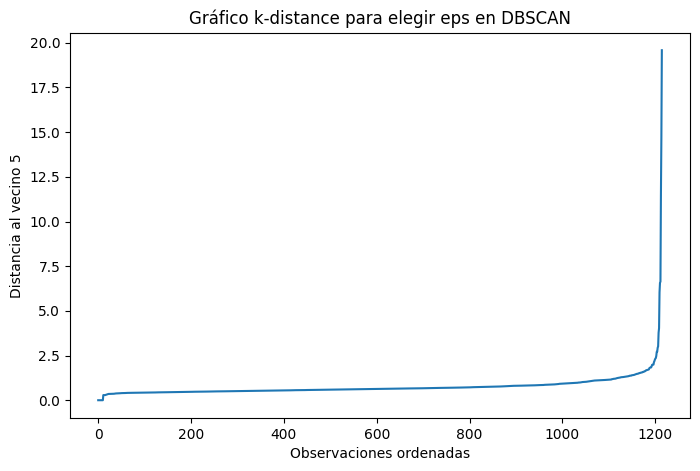

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples_dbscan = 5

neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors_fit = neighbors.fit(X_model)

distances, indices = neighbors_fit.kneighbors(X_model)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Observaciones ordenadas")
plt.ylabel(f"Distancia al vecino {min_samples_dbscan}")
plt.title("Gráfico k-distance para elegir eps en DBSCAN")
plt.show()

En el gráfico k-distance se busca el punto donde la curva comienza a aumentar con mayor rapidez. Ese punto se interpreta como un valor razonable para `eps`, ya que separa las observaciones que pertenecen a regiones densas de aquellas que quedan más aisladas.

In [15]:
eps_dbscan = 1.4
dbscan_final = DBSCAN(eps=eps_dbscan,min_samples=min_samples_dbscan)
df_features["Cluster_DBSCAN"] = dbscan_final.fit_predict(X_model)
df_features["Cluster_DBSCAN"].value_counts().sort_index()

Cluster_DBSCAN
-1      29
 0    1186
Name: count, dtype: int64

In [16]:
resumen_dbscan = df_features.groupby("Cluster_DBSCAN")[
    ["Offense_Total","Defense_Total","Off_Def_Ratio","Speed_Index","Bulk","Phys_Special"]].mean().round(2)
resumen_dbscan

,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
Cluster_DBSCAN,,,,,,
-1,185.34,157.69,1.94,2.80,16445.28,13.69
0,153.62,147.20,1.13,1.04,10940.49,7.79


### Interpretación de DBSCAN

Se aplicó DBSCAN utilizando `min_samples = 5` y `eps = 1.4`. El valor de `min_samples` se escogió porque permite formar regiones densas sin ser excesivamente restrictivo. Al utilizar valores mayores, una proporción más alta de observaciones quedaba clasificada como ruido, dificultando la interpretación.

El valor de `eps` fue seleccionado a partir del gráfico k-distance, observando la zona donde la curva comienza a aumentar con mayor rapidez. Además, se revisaron valores cercanos para obtener una solución interpretable.

Con estos parámetros, DBSCAN generó un cluster principal con 1186 Pokémon, 29 observaciones clasificadas como ruido y algunos clusters pequeños. Esto indica que la mayoría de Pokémon se concentra en una región común del espacio de atributos, mientras que algunos Pokémon presentan combinaciones de estadísticas menos frecuentes.

La etiqueta `-1` corresponde a observaciones clasificadas como ruido. En este caso, estos Pokémon no necesariamente representan errores, sino perfiles de combate más atípicos o extremos.

A diferencia de K-Means y clustering jerárquico, DBSCAN no generó grupos equilibrados en tamaño. Por esta razón, aunque resulta útil para detectar Pokémon atípicos, parece menos adecuado para describir estilos generales de combate en este conjunto de datos.

## 9. Comparación de scoring, descripción de clusters y etiquetado

En esta sección se comparan los resultados obtenidos con K-Means, clustering jerárquico y DBSCAN. Para evaluar la calidad de los agrupamientos se utilizará el Silhouette Score, que mide qué tan similar es una observación respecto a su propio cluster en comparación con otros clusters.

Un valor más alto de Silhouette indica una mejor separación entre grupos. Además del puntaje, también se considerará la interpretabilidad de los clusters y el equilibrio en el tamaño de los grupos.

In [17]:
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

def evaluar_silhouette(X, labels, nombre):
    labels = np.array(labels)

    # Para DBSCAN excluimos el ruido (-1)
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    n_clusters = len(set(labels_eval))
    n_ruido = np.sum(labels == -1)

    # Silhouette necesita al menos 2 clusters
    if n_clusters < 2:
        silhouette = np.nan
    else:
        silhouette = silhouette_score(X_eval, labels_eval)

    return {
        "Modelo": nombre,
        "Clusters": n_clusters,
        "Ruido": n_ruido,
        "Silhouette": silhouette
    }

comparacion_modelos = pd.DataFrame([
    evaluar_silhouette(X_model.values, df_features["Cluster_KMeans"].values, "K-Means"),
    evaluar_silhouette(X_model.values, df_features["Cluster_Hierarchical"].values, "Jerárquico"),
    evaluar_silhouette(X_model.values, df_features["Cluster_DBSCAN"].values, "DBSCAN")
])

comparacion_modelos

,Modelo,Clusters,Ruido,Silhouette
0,K-Means,3,0,0.253108
1,Jerárquico,3,0,0.215910
2,DBSCAN,1,29,NaN


### Comparación mediante Silhouette Score

Para comparar los tres métodos de clustering se utilizó el Silhouette Score. Esta métrica permite evaluar qué tan bien agrupada está cada observación dentro de su propio cluster en comparación con los otros clusters.

Un valor de Silhouette más alto indica que los clusters están mejor separados y que las observaciones dentro de cada grupo son más similares entre sí.

En el caso de DBSCAN, las observaciones clasificadas como ruido, etiquetadas como `-1`, fueron excluidas del cálculo del Silhouette Score, ya que no forman parte de ningún cluster.

In [18]:
print("Distribución K-Means:")
display(df_features["Cluster_KMeans"].value_counts().sort_index())

print("Distribución Jerárquico:")
display(df_features["Cluster_Hierarchical"].value_counts().sort_index())

print("Distribución DBSCAN:")
display(df_features["Cluster_DBSCAN"].value_counts().sort_index())

Distribución K-Means:


Cluster_KMeans
0    488
1    392
2    335
Name: count, dtype: int64

Distribución Jerárquico:


Cluster_Hierarchical
0    538
1    428
2    249
Name: count, dtype: int64

Distribución DBSCAN:


Cluster_DBSCAN
-1      29
 0    1186
Name: count, dtype: int64

### Comparación de tamaños de clusters

Además del Silhouette Score, se revisó la distribución de observaciones en cada método. Esto es importante porque un método puede obtener una métrica aceptable, pero producir clusters poco útiles si genera grupos muy desbalanceados o muchos puntos clasificados como ruido.

Por esta razón, la selección final del método considera tanto el puntaje de evaluación como la interpretabilidad de los grupos generados.

### Selección del método final

Se seleccionó K-Means como método final de clustering.

Aunque DBSCAN permite identificar observaciones atípicas, en este caso clasificó la gran mayoría de Pokémon (1186) en un único cluster principal y dejó 29 observaciones como ruido, sin generar grupos diferenciados. Esto impide describir distintos estilos de combate y, además, el Silhouette Score no pudo ser calculado al existir un solo cluster válido.

El clustering jerárquico permitió observar la estructura de agrupamiento mediante el dendrograma y entregó resultados coherentes, pero K-Means obtuvo un Silhouette Score más alto y produjo clusters más equilibrados en tamaño.

Se seleccionó K-Means con k = 3 como solución final, ya que obtuvo el mayor Silhouette Score entre los métodos comparados: K-Means = 0.2531, clustering jerárquico = 0.2159 y DBSCAN no calculable (un solo cluster). Además, los tres grupos resultantes son interpretables y representan estilos de combate diferenciados.

In [19]:
resumen_kmeans = df_features.groupby("Cluster_KMeans")[
    ["Offense_Total","Defense_Total","Off_Def_Ratio","Speed_Index","Bulk","Phys_Special"]].mean().round(2)
resumen_kmeans

,Offense_Total,Defense_Total,Off_Def_Ratio,Speed_Index,Bulk,Phys_Special
Cluster_KMeans,,,,,,
0,109.02,106.12,1.09,1.21,5745.89,2.94
1,182.04,195.55,0.88,0.92,16446.86,-15.02
2,188.07,151.37,1.55,1.09,12540.81,42.05


Cluster 0 (n = 488):
Valores bajos en casi todas las variables. Offense_Total = 109, Defense_Total = 106, Bulk = 5746 y Phys_Special ≈ 0. Es el grupo con menor rendimiento general en combate. Probablemente agrupa Pokémon de etapas iniciales o con estadísticas globales bajas y sin una orientación clara hacia ataque físico o especial.

Cluster 1 (n = 392):
Alta capacidad defensiva y de supervivencia. Defense_Total = 195, Bulk = 16447 y Phys_Special = −15 (negativo). Esto indica un perfil resistente, con altos valores de defensa física y especial, y mayor orientación al ataque especial que al físico. Velocidad relativa más baja que los otros grupos.

Cluster 2 (n = 335):
Alta ofensiva con clara orientación física. Offense_Total = 188, Off_Def_Ratio = 1.55 y Phys_Special = +42 (muy positivo). El ataque físico supera ampliamente al especial, manteniendo buena velocidad. Corresponde al perfil de atacantes físicos.

In [20]:
etiquetas_kmeans = {
    0: "Bajo rendimiento general",
    1: "Tanques defensivos especiales",
    2: "Atacantes físicos"
}

df_final = df.copy()
df_final["Cluster_Final"] = df_features["Cluster_KMeans"]
df_final["Etiqueta_Cluster"] = df_final["Cluster_Final"].map(etiquetas_kmeans)

df_final[["Name", "Type1", "Type2", "Cluster_Final", "Etiqueta_Cluster"]].head(2000)


,Name,Type1,Type2,Cluster_Final,Etiqueta_Cluster
0,Bulbasaur,Grass,Poison,0,Bajo rendimiento general
1,Ivysaur,Grass,Poison,0,Bajo rendimiento general
2,Venusaur,Grass,Poison,1,Tanques defensivos especiales
3,Charmander,Fire,,0,Bajo rendimiento general
4,Charmeleon,Fire,,0,Bajo rendimiento general
...,...,...,...,...,...
1210,Iron Crown,Steel,Psychic,1,Tanques defensivos especiales
1211,Terapagos,Normal,,1,Tanques defensivos especiales
1212,Terapagos,Normal,,1,Tanques defensivos especiales
1213,Terapagos,Normal,,1,Tanques defensivos especiales


### Descripción y etiquetado de clusters

La solución final seleccionada fue K-Means con k = 3. Esta decisión se tomó porque K-Means obtuvo el mayor Silhouette Score entre los tres métodos comparados y, además, generó grupos de tamaño equilibrado e interpretables.

A partir de los promedios de los atributos originales y de las variables creadas en la etapa de ingeniería de atributos, se asignaron etiquetas descriptivas a los tres clusters.

El cluster 0 fue etiquetado como Bajo rendimiento general, debido a que presenta los valores promedio más bajos en HP, ataque, defensa, ataque especial, defensa especial, velocidad, ofensiva total, defensa total y Bulk.

El cluster 1 fue etiquetado como Tanques defensivos especiales, ya que presenta los valores más altos de Defense_Total y Bulk, junto con un Phys_Special negativo, lo que indica un perfil resistente con orientación más especial que física.

El cluster 2 fue etiquetado como Atacantes físicos, ya que presenta alto Attack, alto Off_Def_Ratio y un valor muy positivo de Phys_Special, lo que indica una orientación marcada hacia el ataque físico con buena velocidad.

Estas etiquetas permiten transformar los resultados numéricos del clustering en perfiles de combate interpretables.

## 10. Sugerencia de uso de los clusters

Los clusters encontrados permiten transformar un conjunto amplio de estadísticas individuales en perfiles de combate más fáciles de interpretar. En vez de analizar por separado HP, Attack, Defense, Sp. Atk, Sp. Def y Speed para cada Pokémon, el profesor Seebach puede utilizar los grupos obtenidos para identificar rápidamente el estilo predominante de cada Pokémon.

La solución final basada en K-Means permitió separar los Pokémon en tres perfiles principales:

Bajo rendimiento general: Pokémon con estadísticas promedio más bajas. Este grupo puede representar Pokémon de etapas iniciales o con menor utilidad competitiva directa.
Tanques defensivos especiales: Pokémon con alta defensa, alto Bulk y mayor capacidad de supervivencia, con orientación más especial que física. Pueden ser utilizados para resistir daño, sostener combates largos o cubrir al equipo frente a atacantes especiales.
Atacantes físicos: Pokémon con alto ataque físico, buena velocidad y orientación clara al combate físico. Pueden ser útiles para estrategias ofensivas donde se busca causar daño directo rápidamente.
Esta clasificación puede ayudar al profesor Seebach a diseñar estrategias de combate más eficientes, seleccionar Pokémon según roles específicos y construir equipos más equilibrados. Por ejemplo, un equipo podría combinar atacantes físicos para iniciar presión ofensiva y tanques defensivos para resistir ataques y sostener el combate.